In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad
import torch

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

In [4]:
seed = 4
num_trajectories = 10000
max_inventory = 20

## Varying Informed trader proportion (psi and phi)

### Parameters

In [5]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6
# p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10.0
k = 1
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [8]:
# OU parameters
u0 = 0.0
xi = 1.0
total_arrivals = 30.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_aux_integral_for_psi_eta(phi):
    """Compute psi for multiple eta values using the discretized integral version."""
    time_grid = np.linspace(0, terminal_time, n_steps)

    v_t = v(time_grid)
    c = gamma * sigma * fads_proportion
    integrand_values = np.exp((c**2) / 2 * v_t)
    aux_integral = terminal_time * np.mean(integrand_values)
    psi = (total_arrivals * terminal_time - phi * terminal_time) / aux_integral

    return psi

def phi_from_informed(perc_informed):
    """
    Given the percentage of informed traders (0-100),
    compute phi according to the paper.
    """
    return 30 * (1 - perc_informed / 100.0)

def psi_from_informed(perc_informed):
    """
    Given percentage of informed traders, compute phi and psi.
    """
    phi = phi_from_informed(perc_informed)
    psi = compute_aux_integral_for_psi_eta(phi)  # eq (61) implementation

    return phi, psi


In [ ]:
def build_phi_psi_dict(percentages):
    results = {}
    for perc in percentages:
        phi, psi = psi_from_informed(perc)
        results[perc] = {"phi": phi, "psi": psi}
    return results

percentages = [0, 25, 50, 75, 100]
phi_psi_dict = build_phi_psi_dict(percentages)
for perc, vals in phi_psi_dict.items():
    print(f"{perc}% informed → phi = {vals['phi']:.2f}, psi = {vals['psi']:.4f}")



0% informed → phi = 30.00, psi = 0.0000
25% informed → phi = 22.50, psi = 7.4362
50% informed → phi = 15.00, psi = 14.8723
75% informed → phi = 7.50, psi = 22.3085
100% informed → phi = 0.00, psi = 29.7447


## Building the enviroment

In [10]:
def get_as_env(num_trajectories:int = 1, phi:float=15.0, psi:float = 15.0):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

### Full Information

In [11]:
results_dict_full_information = {}
for perc, vals in phi_psi_dict.items():
    phi, psi = vals['phi'], vals['psi']
    
    # Set up environment and agent
    vec_env = get_as_env(num_trajectories=num_trajectories, phi=phi, psi=psi)
    vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)
    
    # Generate trajectory and results
    #observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    _, _, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(vec_env=vec_env, agent=vec_as)
    del rewards, total_rewards
    
    # Store in results dictionary keyed by percentage
    results_dict_full_information[perc] = {
        "results": results,
        #"rewards": total_rewards,
        #"obs": observations
    }

✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots/../../mbt_gym/agents/BaselineAgents.py:451: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


✓ Pre-computed ODE solutions for 1000 time points


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots/../../mbt_gym/agents/BaselineAgents.py:451: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


In [12]:
header = f"{'Perc':>6} | {'Phi':>8} | {'Psi':>8} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for perc, result in results_dict_full_information.items():
    phi, psi = phi_psi_dict[perc]['phi'], phi_psi_dict[perc]['psi']
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    
    print(f"{perc:6}% | {phi:8.2f} | {psi:8.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15} | {std_inv:13}")

  Perc |      Phi |      Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
----------------------------------------------------------------------------------------
     0% |    30.00 |   0.0000 |      21.42 |       4.96 |          0.0281 | 3.2149199663444192
    25% |    22.50 |   7.4362 |      21.36 |       4.93 |          0.0271 | 3.177761097061892
    50% |    15.00 |  14.8723 |      21.29 |       4.94 |          0.0323 | 3.154180830263224
    75% |     7.50 |  22.3085 |      21.22 |       4.93 |            0.03 | 3.150222214384249
   100% |     0.00 |  29.7447 |      21.15 |       4.92 |          0.0247 | 3.1463772675888695


### Cartea Jaimungal Penalva

In [13]:
results_dict_CJP = {}
for perc, vals in phi_psi_dict.items():
    phi, psi = vals['phi'], vals['psi']
    
    # Set up environment and agent
    vec_env = get_as_env(num_trajectories=num_trajectories, phi=phi, psi=psi)
    vec_as = ModifiedCarteaJaimungalMmAgent(env=vec_env)
    
    # Generate trajectory and results
    #observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    _, _, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(vec_env=vec_env, agent=vec_as)
    del rewards, total_rewards
    # Store in results dictionary keyed by percentage
    results_dict_CJP[perc] = {
        "results": results,
        #"rewards": total_rewards,
        #"obs": observations
    }

In [14]:
header = f"{'Perc':>6} | {'Phi':>8} | {'Psi':>8} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for perc, result in results_dict_CJP.items():
    phi, psi = phi_psi_dict[perc]['phi'], phi_psi_dict[perc]['psi']
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    
    print(f"{perc:6}% | {phi:8.2f} | {psi:8.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15} | {std_inv:13}")

  Perc |      Phi |      Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
----------------------------------------------------------------------------------------
     0% |    30.00 |   0.0000 |      21.33 |       4.98 |          0.0229 | 3.1389768380795675
    25% |    22.50 |   7.4362 |      21.24 |       4.96 |          0.0268 | 3.1438641446474747
    50% |    15.00 |  14.8723 |      21.16 |       4.95 |          0.0318 | 3.1589537445173206
    75% |     7.50 |  22.3085 |      21.09 |       4.94 |           0.036 | 3.1962640691907795
   100% |     0.00 |  29.7447 |      21.01 |       4.94 |          0.0267 | 3.23694101120178


### Partial Information

In [15]:
results_dict_partial_information = {}
for perc, vals in phi_psi_dict.items():
    phi, psi = vals['phi'], vals['psi']
    
    # Set up environment and agent
    vec_env = get_as_env(num_trajectories=1000, phi=phi, psi=psi)
    vec_as = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)
    
    # Generate trajectory and results
    #observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    _, _, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(vec_env=vec_env, agent=vec_as)
    del rewards, total_rewards
    # Store in results dictionary keyed by percentage
    results_dict_partial_information[perc] = {
        "results": results,
       # "rewards": total_rewards,
       # "obs": observations
    }

✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points


In [16]:
header = f"{'Perc':>6} | {'Phi':>8} | {'Psi':>8} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for perc, result in results_dict_partial_information.items():
    phi, psi = phi_psi_dict[perc]['phi'], phi_psi_dict[perc]['psi']
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    
    print(f"{perc:6}% | {phi:8.2f} | {psi:8.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15} | {std_inv:13}")

  Perc |      Phi |      Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
----------------------------------------------------------------------------------------
     0% |    30.00 |   0.0000 |      21.54 |       5.02 |             0.0 | 3.218073958130857
    25% |    22.50 |   7.4362 |      21.47 |       5.02 |             0.0 | 3.18841653489628
    50% |    15.00 |  14.8723 |      21.38 |       4.97 |          -0.034 | 3.186980389020303
    75% |     7.50 |  22.3085 |      21.28 |       4.98 |          -0.065 | 3.1579700758556912
   100% |     0.00 |  29.7447 |      21.21 |       4.94 |          -0.101 | 3.213844893581518


### Final Plot

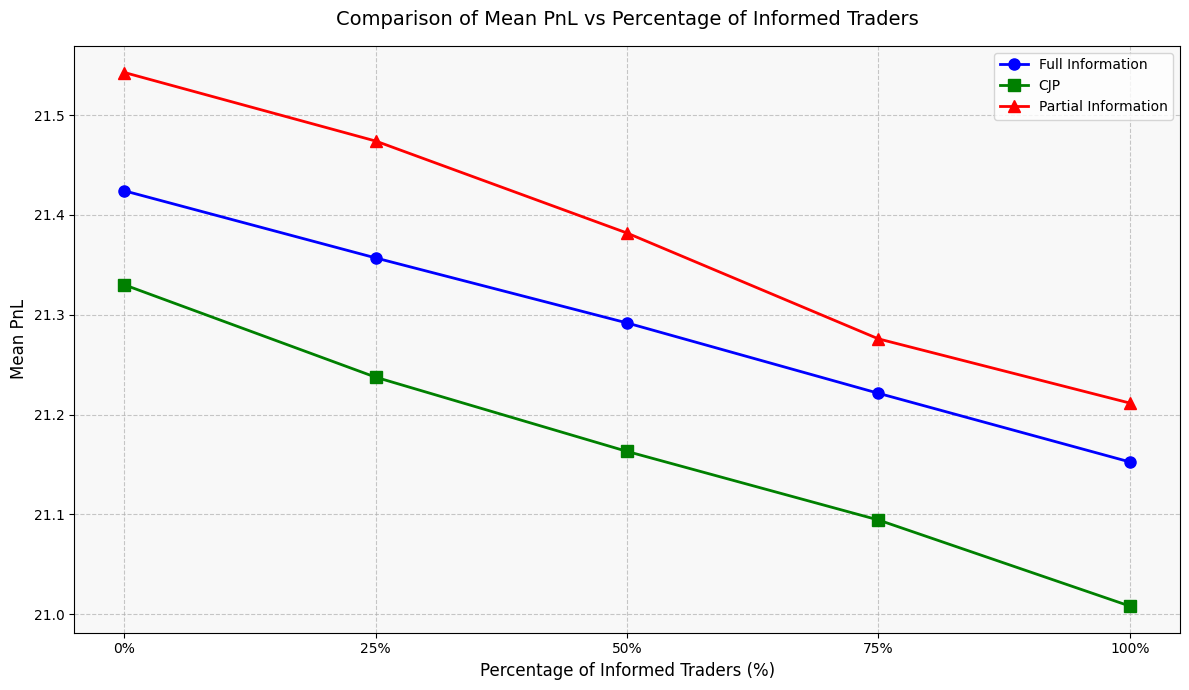

In [17]:
# seed = 7
# Extract mean PnL values for each approach using percentages as keys
percentages = list(phi_psi_dict.keys())  # [0, 25, 50, 75, 100]
mean_pnl_full = [results_dict_full_information[p]['results'].loc['Inventory', 'Mean PnL'] for p in percentages]
mean_pnl_cjp = [results_dict_CJP[p]['results'].loc['Inventory', 'Mean PnL'] for p in percentages]
mean_pnl_partial = [results_dict_partial_information[p]['results'].loc['Inventory', 'Mean PnL'] for p in percentages]

# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(percentages, mean_pnl_full, 'o-', label='Full Information', color='blue', linewidth=2, markersize=8)
plt.plot(percentages, mean_pnl_cjp, 's-', label='CJP', color='green', linewidth=2, markersize=8)
plt.plot(percentages, mean_pnl_partial, '^-', label='Partial Information', color='red', linewidth=2, markersize=8)

plt.xlabel('Percentage of Informed Traders (%)', fontsize=12)
plt.ylabel('Mean PnL', fontsize=12)
plt.title('Comparison of Mean PnL vs Percentage of Informed Traders', fontsize=14, pad=15)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

# Add x-axis ticks at each percentage value
plt.xticks(percentages, [f"{p}%" for p in percentages])

# Add minor gridlines
plt.grid(True, which='minor', linestyle=':', alpha=0.4)

# Format y-axis with larger ticks
plt.tick_params(axis='both', which='major', labelsize=10)

# Add a light gray background grid
plt.gca().set_facecolor('#f8f8f8')

plt.tight_layout()
plt.show()